# BE Model: Foundations & Behaviour

This notebook covers the fundamentals of the Boundary Estimation (BE) model:
- Basic simulation and psychometric analysis
- Burn-in effects (naive vs expert behaviour)
- Parameter effects on behaviour (configurable sweeps)
- MixedAgent analysis (heuristic contamination)

**Companion notebook**: `BE_parameter_recovery_update_matrix.ipynb` covers parameter recovery and update matrix analysis.

---

## Table of Contents

1. [Setup and Configuration](#1.-Setup-and-Configuration)
2. [Basic Model Simulation](#2.-Basic-Model-Simulation)
3. [Psychometric Curve Analysis](#3.-Psychometric-Curve-Analysis)
4. [Burn-in Effects on Behaviour](#4.-Burn-in-Effects-on-Behaviour)
5. [Parameter Sweeps](#5.-Parameter-Sweeps)
6. [MixedAgent Analysis](#6.-MixedAgent-Analysis)
7. [Summary](#7.-Summary)

---

# 1. Setup and Configuration

Import required modules and set global parameters.

**Key configuration variables** are defined here so you can easily modify them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Core utilities
from Helpers.utils import generate_stimuli
from Helpers.psychometry import fit_psychometric, compute_psychometric_gof

# Models - Stateless core (for direct access) and wrapper (for convenience)
from Models.BE_core import BEParams, BEState, BEModel, TrialHistory
from Models.BE_model import BoundaryEstimationModel
from Models.agent import MixedAgent

# Plotting
from Plotting.psychometric import plot_psychometric
from Plotting.session import plot_session
from Plotting.belief import plot_belief_distribution

print("All imports successful!")

All imports successful!


In [2]:
# =============================================================================
# CONFIGURATION - Modify these as needed
# =============================================================================

# True BE parameters for simulation
TRUE_PARAMS = {
    'sigma_percep': 0.15,    # Perceptual noise std
    'A_repulsion': 0.10,     # Serial dependence (repulsion from previous stimulus)
    'eta_learning': 0.35,    # Learning rate - PRIMARY MEASURE for your research
    'eta_relax': 0.12        # Relaxation rate toward uniform prior
}

# Heuristic parameters for MixedAgent
HEURISTIC_PARAMS = {
    'bias': 0.05,            # Slight side bias
    'p_winstay': 0.6,        # Win-stay probability
    'p_loseshift': 0.4,      # Lose-shift probability
    'w_bias': 1.0,
    'w_winstay': 1.0,
    'w_loseshift': 1.0,
    'w_random': 0.5
}

# Simulation settings
N_TRIALS = 300              # Trials per session
SEED = 42                   # Random seed for reproducibility

# Burn-in settings (number of "pre-training" trials)
BURN_IN_NAIVE = 0           # Naive animal: no prior experience
BURN_IN_EXPERT = 1000       # Expert animal: extensive prior experience

print("Configuration:")
print(f"  True params: {TRUE_PARAMS}")
print(f"  N trials: {N_TRIALS}")
print(f"  Burn-in naive: {BURN_IN_NAIVE}, expert: {BURN_IN_EXPERT}")

Configuration:
  True params: {'sigma_percep': 0.15, 'A_repulsion': 0.1, 'eta_learning': 0.35, 'eta_relax': 0.12}
  N trials: 300
  Burn-in naive: 0, expert: 1000


---

# 2. Basic Model Simulation

Demonstrate the BE model's core functionality:
- Create model with specified parameters
- Simulate a session of choices
- Visualise trial-by-trial behaviour

The BE model maintains a **belief distribution** over the category boundary location. On each trial:
1. Perceive stimulus (with noise and serial repulsion)
2. Compute P(choose B) from belief distribution
3. Sample choice
4. Update belief based on feedback

In [3]:
# Create model with expert-level burn-in
model = BoundaryEstimationModel(**TRUE_PARAMS)
model.reset_belief(burn_in=BURN_IN_EXPERT, burn_in_seed=SEED)

# Generate stimuli (uniformly distributed between -1 and 1)
# Categories: stimulus < 0 → A (0), stimulus > 0 → B (1)
stimuli, categories, rng = generate_stimuli(n_trials=N_TRIALS, seed=SEED)

# Simulate session
choices, p_B = model.simulate_session(stimuli, categories, rng=rng, store_history=True)

# Basic performance metrics
accuracy = np.nanmean(choices == categories)
p_choose_B = np.nanmean(choices)

print(f"Session completed:")
print(f"  Accuracy: {accuracy:.1%}")
print(f"  P(choose B): {p_choose_B:.3f} (should be ~0.5 if unbiased)")
print(f"  Final belief mean: {model.state.belief_mean:.4f}")
print(f"  Final belief std: {model.state.belief_std:.4f}")

Session completed:
  Accuracy: 81.0%
  P(choose B): 0.507 (should be ~0.5 if unbiased)
  Final belief mean: -0.2358
  Final belief std: 0.4735


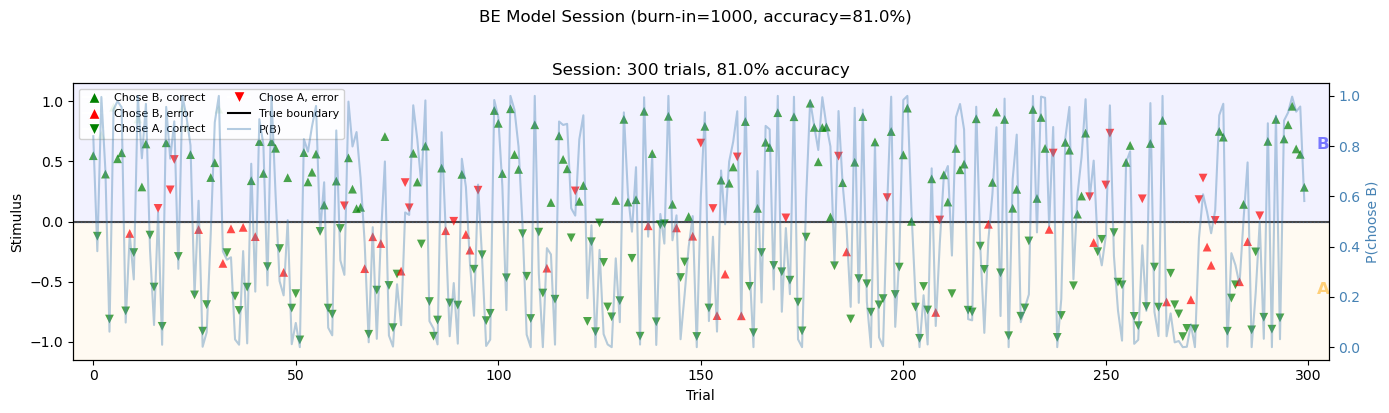

In [4]:
# Visualise session: stimuli, choices, and model's choice probabilities
# Top panel: stimuli coloured by true category
# Middle panel: choices and P(B)
# Bottom panel: cumulative accuracy

fig = plot_session(stimuli, choices, categories, p_B)
fig.suptitle(f'BE Model Session (burn-in={BURN_IN_EXPERT}, accuracy={accuracy:.1%})', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Alternative: Use the stateless core directly
# This is what you'd use for SBI or MCMC inference

params = BEParams(**TRUE_PARAMS)
initial_state = BEModel.create_initial_state(
    burn_in=BURN_IN_EXPERT, 
    params=params, 
    seed=SEED
)

# Simulate with explicit state management
rng_core = np.random.default_rng(SEED)
choices_core, p_B_core, final_state, history = BEModel.simulate_session(
    params, initial_state, stimuli, categories, rng_core,
    return_history=True  # Store beliefs for later analysis
)

print(f"Stateless core simulation:")
print(f"  Accuracy: {np.nanmean(choices_core == categories):.1%}")
print(f"  History stored: {history.n_trials} trials, beliefs shape {history.beliefs.shape}")

Stateless core simulation:
  Accuracy: 79.0%
  History stored: 300 trials, beliefs shape (300, 500)


---

# 3. Psychometric Curve Analysis

The **psychometric curve** shows P(choose B) as a function of stimulus value.

Key parameters:
- **μ (PSE)**: Point of subjective equality - where P(B) = 0.5
- **σ (slope)**: Sensitivity - smaller = steeper curve = better discrimination
- **lapse rates**: Asymptotic error rates at extreme stimuli

In [6]:
# Fit psychometric curve to simulated choices
psych_result = fit_psychometric(stimuli, choices, n_bootstrap=100)

print("Psychometric fit results:")
print(f"  μ (PSE):      {psych_result['mu']:.4f} (ideal: 0.0)")
print(f"  σ (slope):    {psych_result['sigma']:.4f}")
print(f"  lapse_low:    {psych_result['lapse_low']:.4f}")
print(f"  lapse_high:   {psych_result['lapse_high']:.4f}")
print(f"  Fit success:  {psych_result['success']}")

# Bootstrap confidence intervals (if available)
if 'mu_ci' in psych_result:
    print(f"\n  μ 95% CI: [{psych_result['mu_ci'][0]:.4f}, {psych_result['mu_ci'][1]:.4f}]")
    print(f"  σ 95% CI: [{psych_result['sigma_ci'][0]:.4f}, {psych_result['sigma_ci'][1]:.4f}]")

Psychometric fit results:
  μ (PSE):      -0.0430 (ideal: 0.0)
  σ (slope):    0.4691
  lapse_low:    0.0000
  lapse_high:   0.0000
  Fit success:  True

  μ 95% CI: [-0.1477, 0.0866]
  σ 95% CI: [0.3119, 0.5216]


In [7]:
# Goodness of fit
gof = compute_psychometric_gof(stimuli, choices, psych_result)

print("Goodness of fit:")
print(f"  R²:                 {gof['r_squared']:.3f}")
print(f"  Deviance explained: {gof['deviance_explained']:.3f}")

Goodness of fit:
  R²:                 0.984
  Deviance explained: 0.420


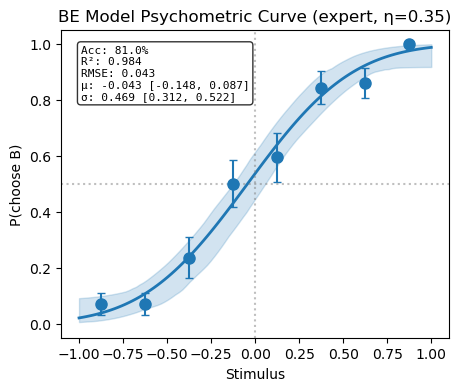

In [8]:
# Plot psychometric curve with data points and confidence bands
fig, info = plot_psychometric(
    stimuli, choices,
    show_gof=True,
    show_params=True,
    n_bootstrap=100,
    title=f'BE Model Psychometric Curve (expert, η={TRUE_PARAMS["eta_learning"]})'
)
plt.show()

---

# 4. Burn-in Effects on Behaviour

**Burn-in** simulates prior experience before the recorded session:
- `burn_in=0`: **Naive** animal - starts with uniform belief (no prior knowledge)
- `burn_in=1000`: **Expert** animal - belief has converged to stable distribution

This is crucial for your research:
- **Naive** → Context learning phase (high effective learning rate)
- **Expert** → Inference phase (stable, low effective learning rate)

We'll compare:
1. Belief distributions after different burn-in
2. Psychometric curves
3. Accuracy and other metrics

In [9]:
# Compare burn-in levels
burn_in_values = [0, 100, 500, 1000, 2000]

# Store results
burn_in_results = []

for burn_in in burn_in_values:
    # Create fresh model and state
    params = BEParams(**TRUE_PARAMS)
    initial_state = BEModel.create_initial_state(
        burn_in=burn_in, params=params, seed=SEED
    )
    
    # Simulate
    rng = np.random.default_rng(SEED + burn_in)  # Different seed per condition
    choices_bi, p_B_bi, final_state, _ = BEModel.simulate_session(
        params, initial_state, stimuli, categories, rng
    )
    
    # Fit psychometric
    psych = fit_psychometric(stimuli, choices_bi)
    
    # Store
    burn_in_results.append({
        'burn_in': burn_in,
        'accuracy': np.nanmean(choices_bi == categories),
        'initial_belief_std': initial_state.belief_std,
        'final_belief_std': final_state.belief_std,
        'mu': psych['mu'],
        'sigma': psych['sigma'],
        'choices': choices_bi,
        'initial_belief': initial_state.boundary_belief.copy(),
        'x': initial_state.x.copy()
    })

# Display summary
df_burnin = pd.DataFrame(burn_in_results)[['burn_in', 'accuracy', 'initial_belief_std', 'mu', 'sigma']]
print("Burn-in comparison:")
print(df_burnin.to_string(index=False))

Burn-in comparison:
 burn_in  accuracy  initial_belief_std        mu    sigma
       0  0.793333            0.577353  0.103687 0.480768
     100  0.813333            0.479933 -0.089526 0.394843
     500  0.790000            0.414334  0.042731 0.480384
    1000  0.780000            0.447056  0.108577 0.425926
    2000  0.820000            0.418059  0.003409 0.332136


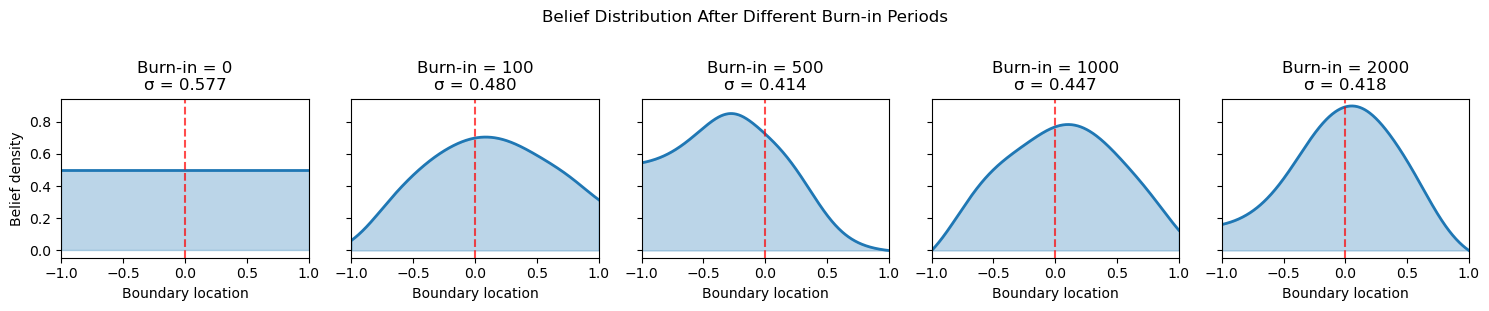

In [10]:
# Plot belief distributions after different burn-in
fig, axes = plt.subplots(1, len(burn_in_values), figsize=(3 * len(burn_in_values), 3), sharey=True)

for i, result in enumerate(burn_in_results):
    ax = axes[i]
    plot_belief_distribution(
        result['x'], result['initial_belief'],
        ax=ax,
        true_boundary=0.0,
        fill=True,
        title=f'Burn-in = {result["burn_in"]}\nσ = {result["initial_belief_std"]:.3f}'
    )
    if i > 0:
        ax.set_ylabel('')  # Only show y-label on first plot

fig.suptitle('Belief Distribution After Different Burn-in Periods', y=1.02)
plt.tight_layout()
plt.show()

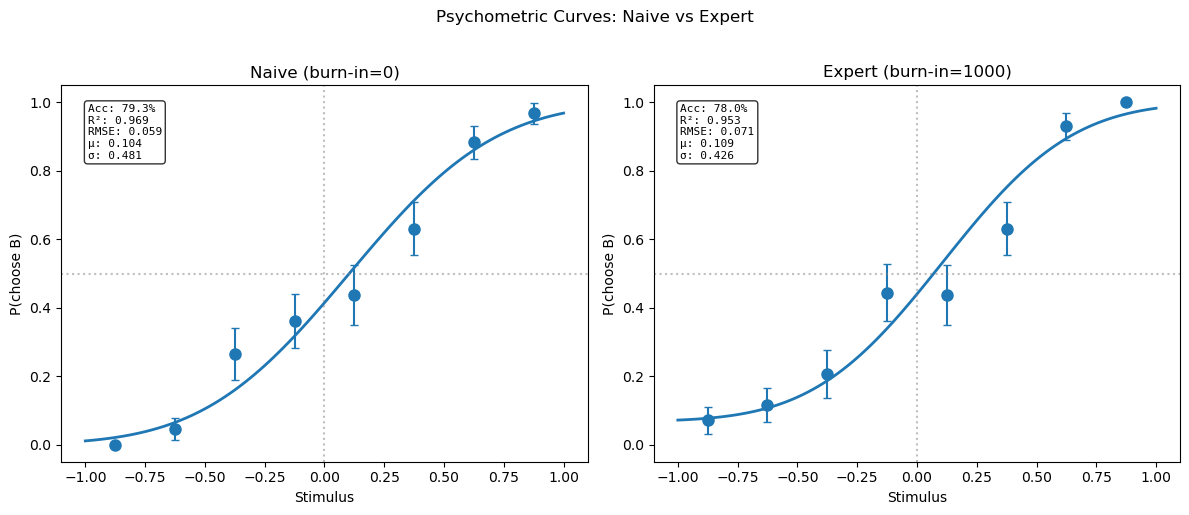

In [11]:
# Plot psychometric curves for naive vs expert
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive (burn_in = 0)
naive_result = burn_in_results[0]
ax = axes[0]
plot_psychometric(
    stimuli, naive_result['choices'],
    show_gof=True, show_params=True,
    title=f'Naive (burn-in={BURN_IN_NAIVE})',
    ax=ax
)

# Expert (burn_in = 1000)
expert_result = [r for r in burn_in_results if r['burn_in'] == 1000][0]
ax = axes[1]
plot_psychometric(
    stimuli, expert_result['choices'],
    show_gof=True, show_params=True,
    title=f'Expert (burn-in={BURN_IN_EXPERT})',
    ax=ax
)

fig.suptitle('Psychometric Curves: Naive vs Expert', y=1.02)
plt.tight_layout()
plt.show()


---

# 5. Parameter Sweeps

Explore how each BE parameter affects behaviour.

**Configure `PARAM_INTEREST`** below to sweep different parameters:
- `'eta_learning'`: Learning rate (your primary research measure)
- `'eta_relax'`: Relaxation rate
- `'sigma_percep'`: Perceptual noise
- `'A_repulsion'`: Serial dependence strength

In [12]:
# =============================================================================
# CONFIGURATION: Choose which parameter to sweep
# =============================================================================

PARAM_INTEREST = 'eta_learning'  # Options: 'eta_learning', 'eta_relax', 'sigma_percep', 'A_repulsion'

# Parameter ranges for sweeps
PARAM_RANGES = {
    'sigma_percep': np.linspace(0.08, 0.4, 6),
    'A_repulsion': np.linspace(0.0, 0.4, 6),
    'eta_learning': np.linspace(0.1, 0.7, 6),
    'eta_relax': np.linspace(0.05, 0.3, 6)
}

sweep_values = PARAM_RANGES[PARAM_INTEREST]
print(f"Sweeping {PARAM_INTEREST}: {sweep_values}")

Sweeping eta_learning: [0.1  0.22 0.34 0.46 0.58 0.7 ]


In [13]:
# Run parameter sweep
sweep_results = []

for val in sweep_values:
    # Create params with swept value
    params_dict = TRUE_PARAMS.copy()
    params_dict[PARAM_INTEREST] = val
    
    params = BEParams(**params_dict)
    initial_state = BEModel.create_initial_state(
        burn_in=BURN_IN_EXPERT, params=params, seed=SEED
    )
    
    # Simulate
    rng = np.random.default_rng(SEED)
    choices_sw, p_B_sw, final_state, _ = BEModel.simulate_session(
        params, initial_state, stimuli, categories, rng
    )
    
    # Fit psychometric
    psych = fit_psychometric(stimuli, choices_sw)
    
    sweep_results.append({
        'param_value': val,
        'accuracy': np.nanmean(choices_sw == categories),
        'mu': psych['mu'],
        'sigma': psych['sigma'],
        'choices': choices_sw
    })

# Display
df_sweep = pd.DataFrame(sweep_results)[['param_value', 'accuracy', 'mu', 'sigma']]
df_sweep.columns = [PARAM_INTEREST, 'accuracy', 'PSE (μ)', 'slope (σ)']
print(f"\nSweep results for {PARAM_INTEREST}:")
print(df_sweep.to_string(index=False))


Sweep results for eta_learning:
 eta_learning  accuracy  PSE (μ)  slope (σ)
         0.10  0.770000 0.101644   0.546882
         0.22  0.800000 0.088092   0.466398
         0.34  0.793333 0.103427   0.484009
         0.46  0.783333 0.098059   0.493603
         0.58  0.783333 0.070175   0.508390
         0.70  0.790000 0.038649   0.494310


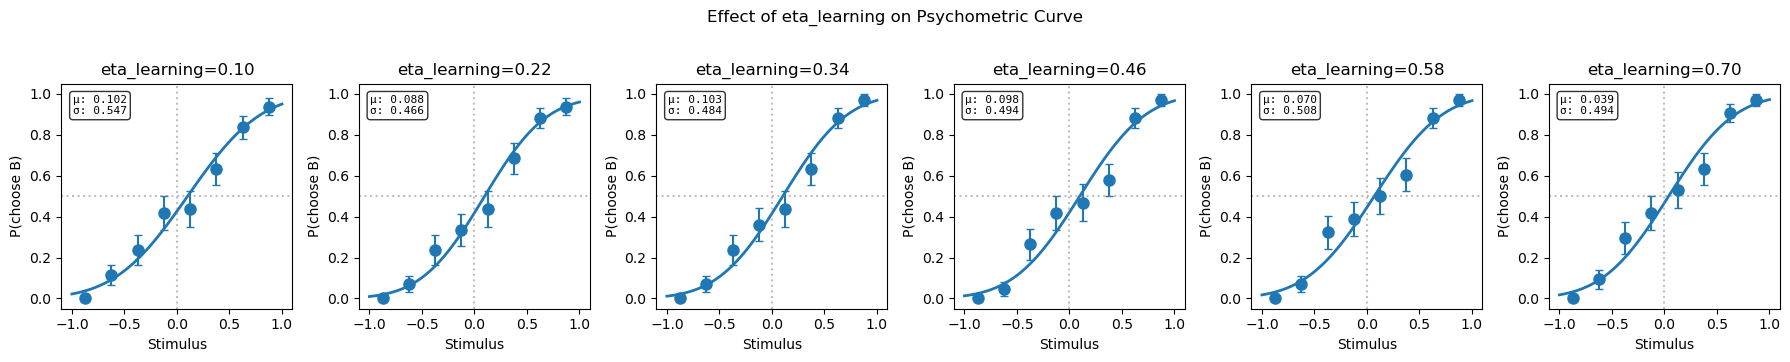

In [14]:
# Plot psychometric curves across sweep
n_vals = len(sweep_values)
fig, axes = plt.subplots(1, n_vals, figsize=(3 * n_vals, 3.5))

for i, result in enumerate(sweep_results):
    ax = axes[i] if n_vals > 1 else axes
    plot_psychometric(
        stimuli, result['choices'],
        show_gof=False, show_params=True,
        title=f'{PARAM_INTEREST}={result["param_value"]:.2f}',
        ax=ax
    )

fig.suptitle(f'Effect of {PARAM_INTEREST} on Psychometric Curve', y=1.02)
plt.tight_layout()
plt.show()

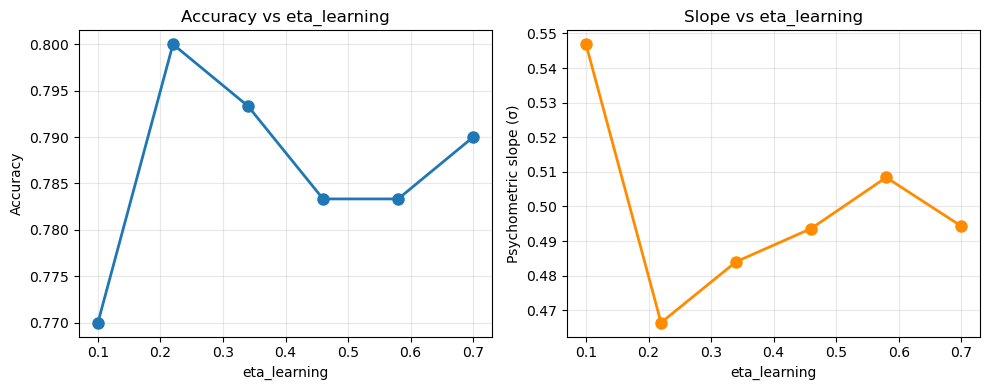

In [15]:
# Summary plot: accuracy and slope vs parameter
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

param_vals = [r['param_value'] for r in sweep_results]
accuracies = [r['accuracy'] for r in sweep_results]
sigmas = [r['sigma'] for r in sweep_results]

# Accuracy
ax = axes[0]
ax.plot(param_vals, accuracies, 'o-', markersize=8, linewidth=2)
ax.set_xlabel(PARAM_INTEREST)
ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy vs {PARAM_INTEREST}')
ax.grid(True, alpha=0.3)

# Slope
ax = axes[1]
ax.plot(param_vals, sigmas, 'o-', markersize=8, linewidth=2, color='darkorange')
ax.set_xlabel(PARAM_INTEREST)
ax.set_ylabel('Psychometric slope (σ)')
ax.set_title(f'Slope vs {PARAM_INTEREST}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# 6. MixedAgent Analysis

The **MixedAgent** combines BE model with heuristic strategies:
- Win-stay / Lose-shift
- Side bias
- Random responding

This tests:
1. How heuristic contamination affects behaviour
2. What happens when you fit pure BE to contaminated data

**`be_weight`** controls the mixture:
- `be_weight=1.0`: Pure BE model
- `be_weight=0.5`: 50% BE, 50% heuristics
- `be_weight=0.0`: Pure heuristics

In [16]:
# BE weights to test
BE_WEIGHTS = [1.0, 0.7, 0.5, 0.3]

mixed_results = []

for be_weight in BE_WEIGHTS:
    # Create MixedAgent - uses 'alpha' for BE weight
    agent = MixedAgent(
        sigma_percep=TRUE_PARAMS['sigma_percep'],
        A_repulsion=TRUE_PARAMS['A_repulsion'],
        eta_learning=TRUE_PARAMS['eta_learning'],
        eta_relax=TRUE_PARAMS['eta_relax'],
        alpha=be_weight,
        bias=HEURISTIC_PARAMS['bias'],
        p_winstay=HEURISTIC_PARAMS['p_winstay'],
        p_loseshift=HEURISTIC_PARAMS['p_loseshift'],
        w_bias=HEURISTIC_PARAMS['w_bias'],
        w_winstay=HEURISTIC_PARAMS['w_winstay'],
        w_loseshift=HEURISTIC_PARAMS['w_loseshift'],
        w_random=HEURISTIC_PARAMS['w_random'],
        burn_in=BURN_IN_EXPERT,
        burn_in_seed=SEED
    )
    
    # Simulate
    rng = np.random.default_rng(SEED)
    choices_mix, _ = agent.simulate_session(stimuli, categories, rng=rng)
    
    # Fit psychometric
    psych = fit_psychometric(stimuli, choices_mix)
    
    mixed_results.append({
        'be_weight': be_weight,
        'accuracy': np.nanmean(choices_mix == categories),
        'mu': psych['mu'],
        'sigma': psych['sigma'],
        'choices': choices_mix
    })

# Display
df_mixed = pd.DataFrame(mixed_results)[['be_weight', 'accuracy', 'mu', 'sigma']]
print("MixedAgent results:")
print(df_mixed.to_string(index=False))

MixedAgent results:
 be_weight  accuracy       mu    sigma
       1.0  0.783333 0.132052 0.466200
       0.7  0.686667 0.194553 0.482682
       0.5  0.636667 0.168112 0.445488
       0.3  0.563333 1.000000 9.999597


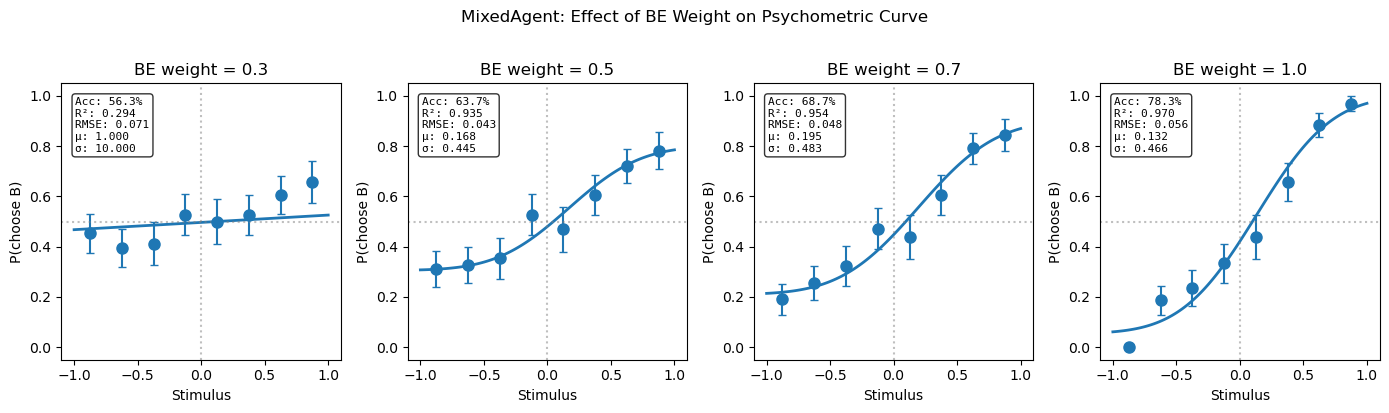

In [17]:
# Plot psychometric curves for different BE weights
n_weights = len(BE_WEIGHTS)
fig, axes = plt.subplots(1, n_weights, figsize=(3.5 * n_weights, 4))

for i, result in enumerate(mixed_results):
    ax = axes[n_weights - i - 1]
    plot_psychometric(
        stimuli, result['choices'],
        show_gof=True, show_params=True,
        title=f'BE weight = {result["be_weight"]:.1f}',
        ax=ax
    )

fig.suptitle('MixedAgent: Effect of BE Weight on Psychometric Curve', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Fit pure BE model to MixedAgent data
# This shows what happens when you ignore heuristic contamination

print("Fitting pure BE model to MixedAgent data...\n")

fit_results_mixed = []

for result in mixed_results:
    be_weight = result['be_weight']
    choices_mix = result['choices']
    
    # Fit BE model
    try:
        fitted_model, fit_info = BoundaryEstimationModel.fit(
            stimuli=stimuli,
            categories=categories,
            observed_choices=choices_mix,
            burn_in=BURN_IN_EXPERT,
            burn_in_seed=SEED,
            n_restarts=3,
            seed=SEED,
            validation='holdout'
        )
        
        fit_results_mixed.append({
            'be_weight': be_weight,
            'true_eta': TRUE_PARAMS['eta_learning'],
            'fitted_eta': fit_info['params']['eta_learning'],
            'true_sigma': TRUE_PARAMS['sigma_percep'],
            'fitted_sigma': fit_info['params']['sigma_percep'],
            'nll': fit_info['test_nll']
        })
        print(f"BE weight={be_weight:.1f}: η_fitted={fit_info['params']['eta_learning']:.3f} (true={TRUE_PARAMS['eta_learning']:.3f})")
        
    except Exception as e:
        print(f"BE weight={be_weight:.1f}: Fitting failed - {e}")

# Summary
if fit_results_mixed:
    df_fit_mixed = pd.DataFrame(fit_results_mixed)
    print("\nRecovery summary:")
    print(df_fit_mixed.to_string(index=False))

Fitting pure BE model to MixedAgent data...

BE weight=1.0: Fitting failed - type object 'BoundaryEstimationModel' has no attribute 'fit'
BE weight=0.7: Fitting failed - type object 'BoundaryEstimationModel' has no attribute 'fit'
BE weight=0.5: Fitting failed - type object 'BoundaryEstimationModel' has no attribute 'fit'
BE weight=0.3: Fitting failed - type object 'BoundaryEstimationModel' has no attribute 'fit'


**Key observation**: As BE weight decreases (more heuristic contamination), the fitted parameters diverge from true values. This is expected - the pure BE model cannot capture heuristic behaviour.

---

# 7. Summary

## Key Findings

### Burn-in Effects
- **Naive (burn_in=0)**: Wide belief distribution, lower accuracy, more variable behaviour
- **Expert (burn_in=1000+)**: Narrow belief centred on true boundary, high accuracy, stable behaviour

### Parameter Effects
- **η_learning**: Higher → more recency bias, faster adaptation but also more variable
- **η_relax**: Higher → faster forgetting, belief returns to uniform faster
- **σ_percep**: Higher → noisier perception, flatter psychometric curve
- **A_repulsion**: Higher → stronger serial dependence (repulsion from previous stimulus)

### MixedAgent
- Heuristic contamination degrades psychometric curve quality
- Fitting pure BE to contaminated data biases parameter estimates

## Next Steps

See **`BE_parameter_recovery_update_matrix.ipynb`** for:
- Systematic parameter recovery analysis
- Update matrix computation and comparison
- Validation of recovery across conditions

In [19]:
print("Notebook 1 complete!")
print("\nContinue to: BE_parameter_recovery_update_matrix.ipynb")

Notebook 1 complete!

Continue to: BE_parameter_recovery_update_matrix.ipynb
